# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



---> 0.xls

---> 1.xls

---> 2.txt

---> 3.txt

---> 4.txt

---> 5.txt


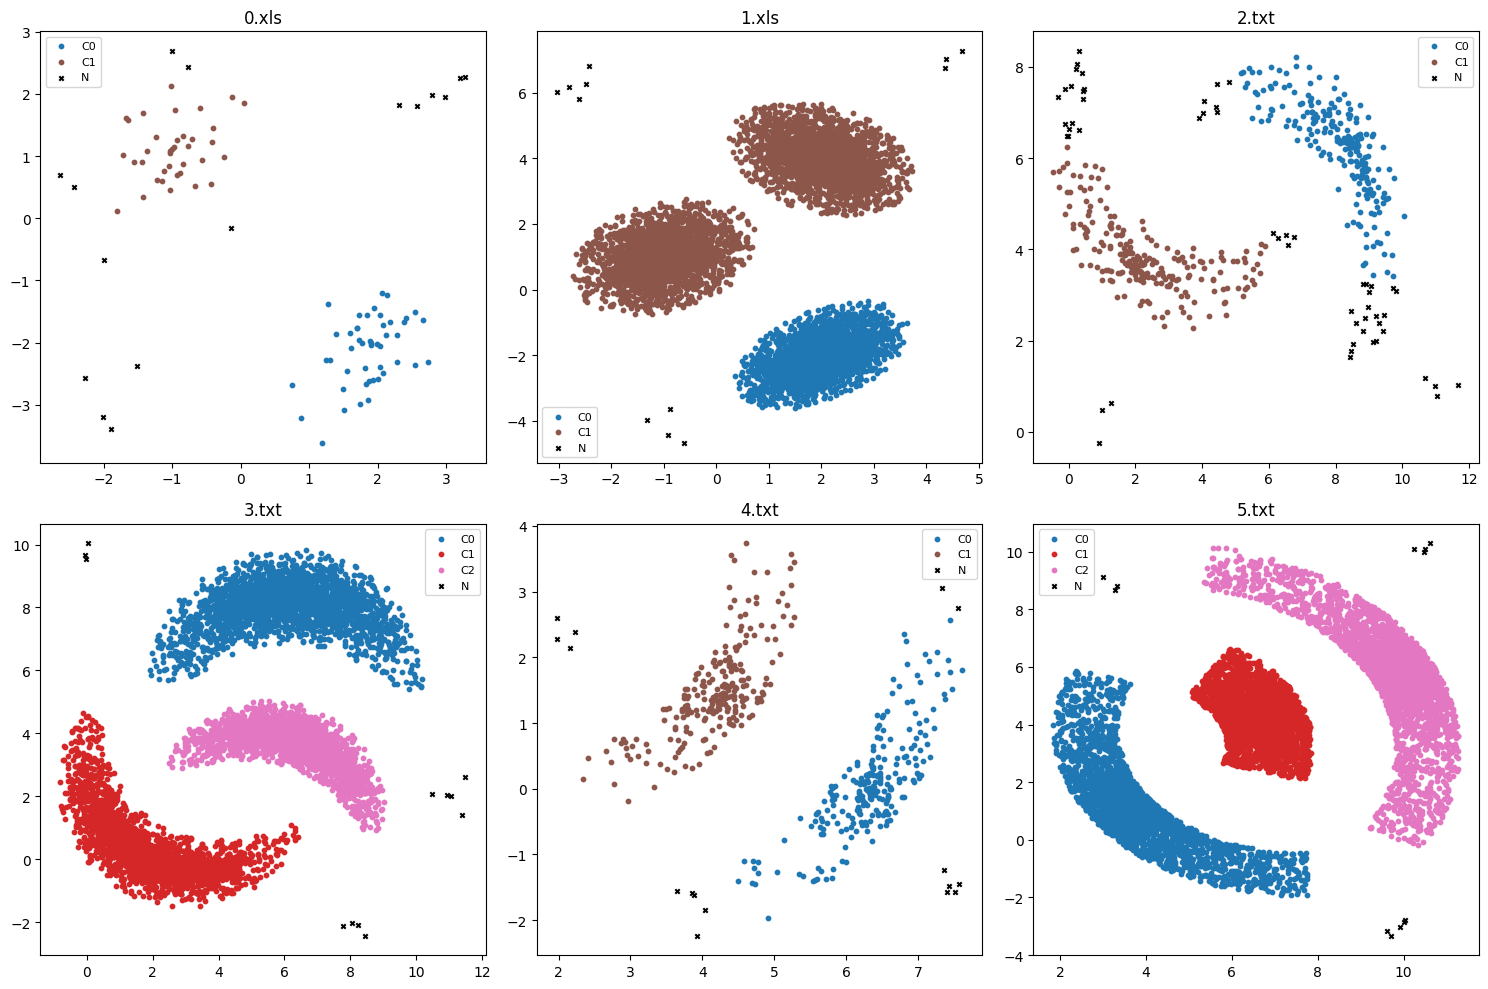


X_avg: 415905.400372
Y_avg: 243346.497539


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import os

def cluster_finder(arr, r, m):
    n1 = len(arr)
    out = np.full(n1, -1)
    seen = np.zeros(n1, bool)
    cid = 0
    diff1 = arr[:, np.newaxis, :] - arr[np.newaxis, :, :]
    sq1 = (diff1 ** 2).sum(axis=2)
    mat = np.sqrt(sq1)
    for i1 in range(n1):
        if seen[i1]:
            continue
        seen[i1] = True
        neigh = np.where(mat[i1] <= r)[0]
        if len(neigh) < m:
            continue
        out[i1] = cid
        q = deque(neigh)
        while q:
            j1 = q.popleft()
            if not seen[j1]:
                seen[j1] = True
                jn = np.where(mat[j1] <= r)[0]
                if len(jn) >= m:
                    q.extend(jn)
            if out[j1] == -1:
                out[j1] = cid
        cid += 1
    return out

fl = ['0.xls', '1.xls', '2.txt', '3.txt', '4.txt', '5.txt']
all_c = []

plt.figure(figsize=(15, 10))

for p, nm in enumerate(fl):
    print(f"\n---> {nm}")
    if nm.endswith('.xls'):
        d = pd.read_excel(nm)
    else:
        d = pd.read_csv(nm)
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d.dropna()
    vals = d.values.astype(float)
    lbls = cluster_finder(vals, 1.0, 30)
    uniq = set(lbls)
    uniq.discard(-1)
    for uc in uniq:
        pts = vals[lbls == uc]
        d2 = pts[:, np.newaxis, :] - pts[np.newaxis, :, :]
        dm = np.sqrt((d2 ** 2).sum(axis=2))
        sd = dm.sum(axis=1)
        bi = np.argmin(sd)
        bp = pts[bi]
        all_c.append(bp)
    plt.subplot(2, 3, p + 1)
    clrs = plt.cm.tab10(np.linspace(0, 1, len(uniq) + 1))
    for uc in uniq:
        plt.scatter(vals[lbls == uc, 0], vals[lbls == uc, 1], color=clrs[uc], label=f'C{uc}', s=10)
    plt.scatter(vals[lbls == -1, 0], vals[lbls == -1, 1], color='black', marker='x', label='N', s=10)
    plt.title(nm)
    plt.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

if all_c:
    cc = np.array(all_c)
    mx = np.mean(cc[:, 0]) * 100000
    my = np.mean(cc[:, 1]) * 100000
    print(f"\nX_avg: {mx:.6f}")
    print(f"Y_avg: {my:.6f}")
else:
    print("\nNothing found")

# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [6]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

In [7]:
from sklearn import cluster, mixture

two_means = cluster.KMeans(n_clusters=2)
dbscan = cluster.DBSCAN(eps=0.3)

ms = cluster.MeanShift()
spectral = cluster.SpectralClustering(n_clusters=2, eigen_solver='arpack', affinity='nearest_neighbors')
ward = cluster.AgglomerativeClustering(n_clusters=2, linkage='ward')

average_linkage = cluster.AgglomerativeClustering(linkage='average', metric='cityblock', n_clusters=2)
optics = cluster.OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.1)
gmm = mixture.GaussianMixture(n_components=2)

clustering_algorithms = (
    ('KMeans', two_means),
    ('DBSCAN', dbscan),
    ('MeanShift', ms),
    ('Spectral\nClustering', spectral),
    ('Ward', ward),
    ('Agglomerative\nClustering', average_linkage),
    ('OPTICS', optics),
    ('Gaussian\nMixture', gmm),
)

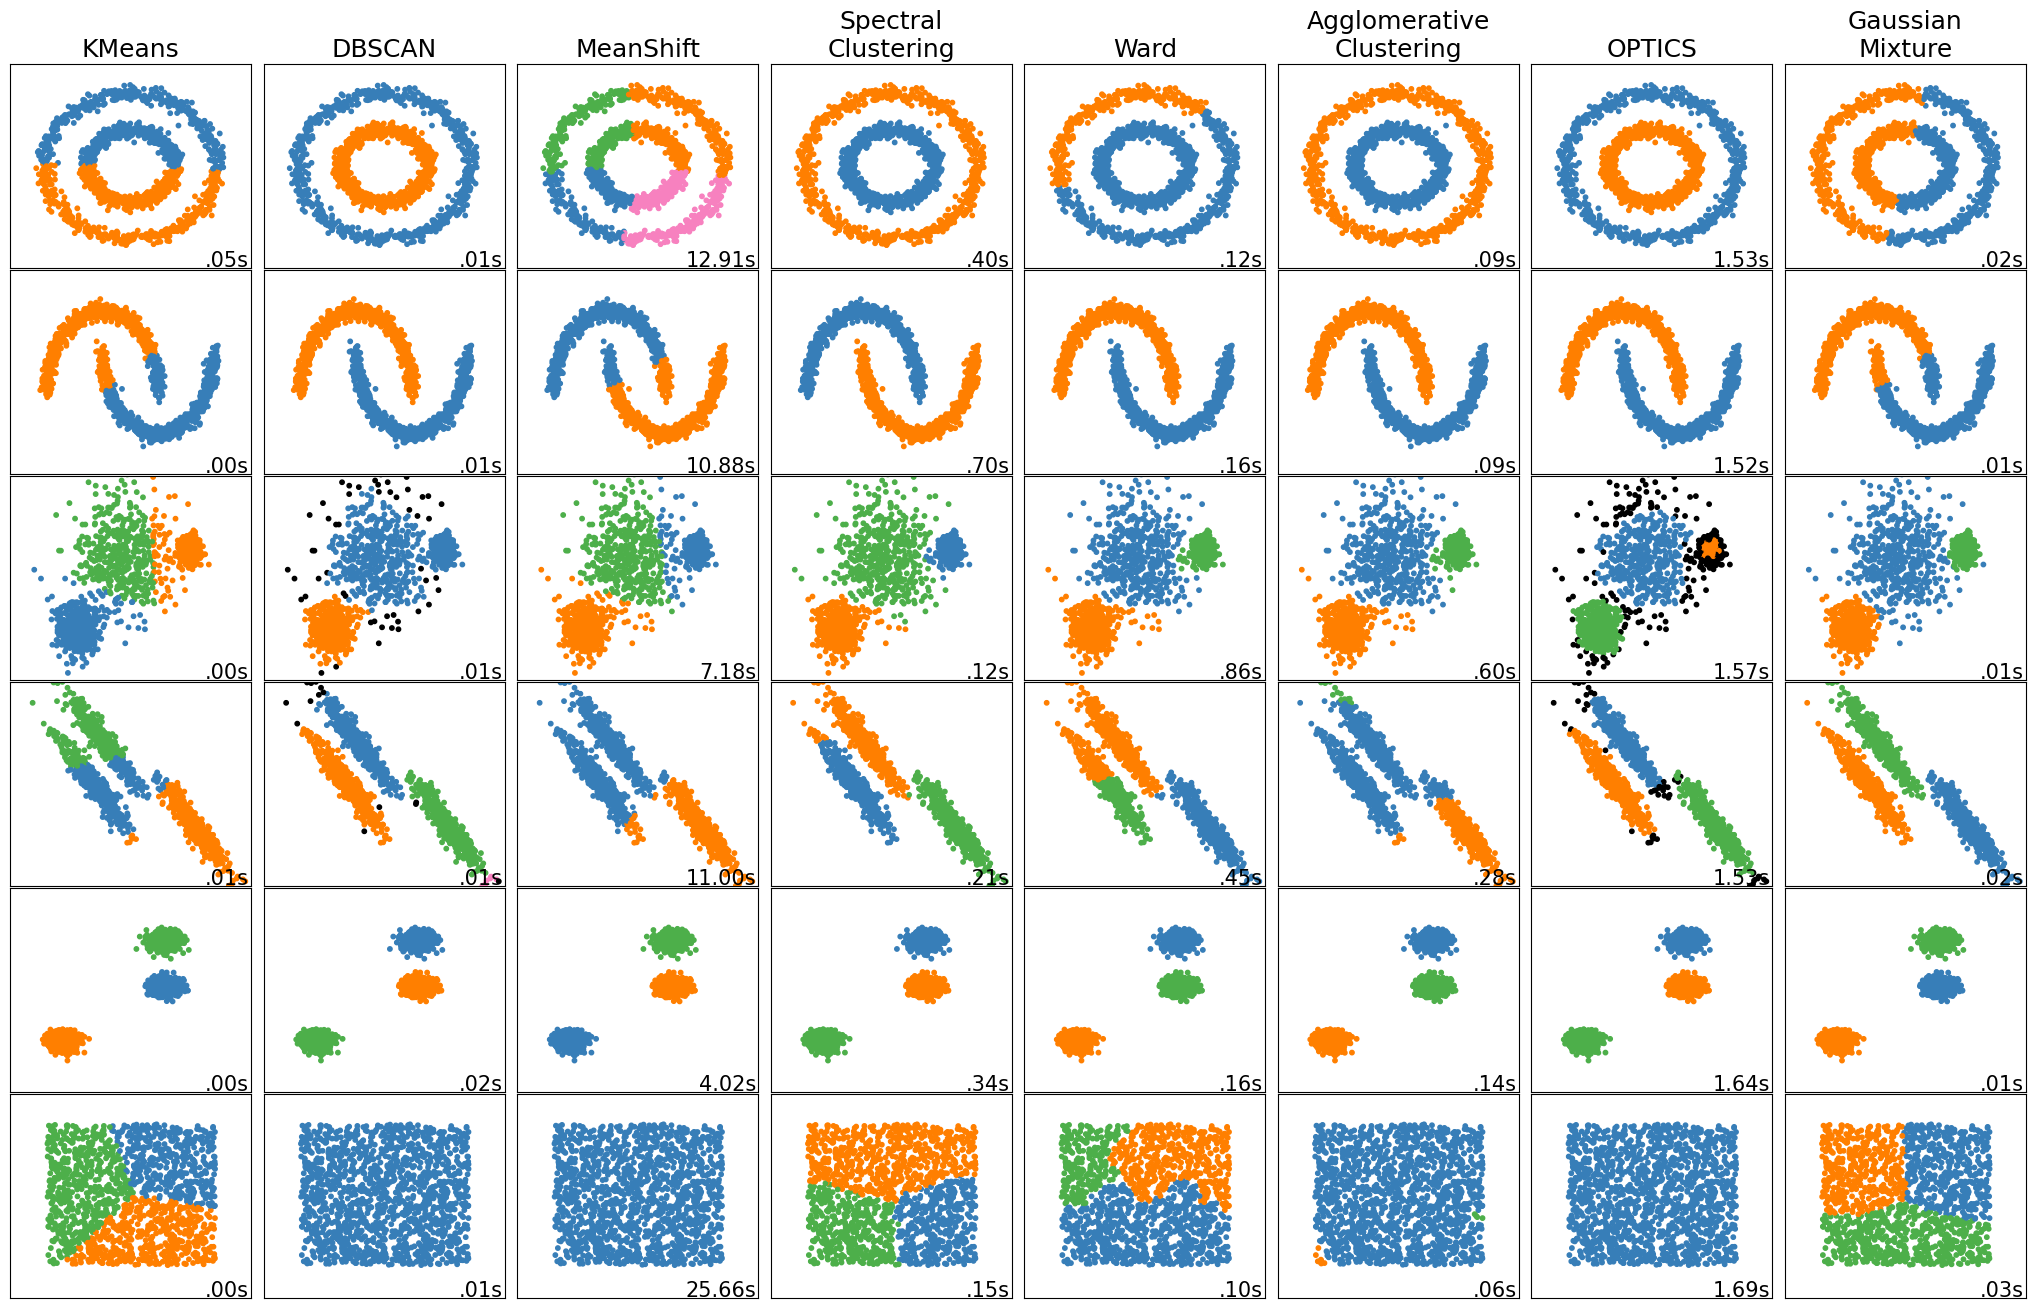

In [8]:
np.random.seed(0)

n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

dataset_list = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(dataset_list):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    X = StandardScaler().fit_transform(X)

    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    connectivity = 0.5 * (connectivity + connectivity.T)

    two_means = cluster.KMeans(n_clusters=params["n_clusters"])
    dbscan = cluster.DBSCAN(eps=params["eps"])
    ms = cluster.MeanShift(bandwidth=bandwidth)
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver='arpack',
        affinity='nearest_neighbors'
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
        linkage='ward'
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage='average',
        metric='cityblock',
        n_clusters=params["n_clusters"],
        connectivity=connectivity
    )
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"]
    )
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type='full'
    )

    clustering_algorithms = (
        ('KMeans', two_means),
        ('DBSCAN', dbscan),
        ('MeanShift', ms),
        ('Spectral\nClustering', spectral),
        ('Ward', ward),
        ('Agglomerative\nClustering', average_linkage),
        ('OPTICS', optics),
        ('Gaussian\nMixture', gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                "connectivity matrix is [0-9]{1,2}"
                " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                " may not work as expected.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(dataset_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                               '#f781bf', '#a65628', '#984ea3',
                               '#999999', '#e41a1c', '#dede00']),
                        int(max(y_pred) + 1)))
        )

        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()